# 03. BERT 감정분석

**모델**: `distilbert-base-uncased` (BERT의 경량화 버전)

## 왜 DistilBERT?
- bert-base와 거의 동일한 성능 (~97%) 이지만 학습 시간 2~3배 단축
- 본 데이터셋(27k tweet)에는 충분히 강력함
- 시간 여유 있으면 `bert-base-uncased`로 바꿔 비교 가능

### 0. Google Drive 마운트 및 경로 설정

In [1]:
# Google Drive 마운트
import os, sys

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/sentiment_analysis'
    IN_COLAB = True
except ImportError:
    # 로컬 환경에서 실행할 경우: 현재 디렉토리 기준
    PROJECT_DIR = '.'
    IN_COLAB = False
    print('로컬 환경에서 실행 중')

# 하위 폴더 정의
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# utils.py import 경로 추가
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

print(f'프로젝트 경로: {PROJECT_DIR}')
print(f'데이터 경로 : {DATA_DIR}')
print(f'결과 경로  : {RESULTS_DIR}')

Mounted at /content/drive
프로젝트 경로: /content/drive/MyDrive/sentiment_analysis
데이터 경로 : /content/drive/MyDrive/sentiment_analysis/data
결과 경로  : /content/drive/MyDrive/sentiment_analysis/results


### 1. 패키지 설치 (Colab 첫 실행 시)

In [2]:
!pip install -q transformers datasets accelerate evaluate
# 패키지 설치 후 런타임 재시작 필요할 수 있음

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00


In [3]:
import time, json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
)
from sklearn.metrics import accuracy_score, f1_score

from utils import (load_data, evaluate_model, plot_confusion_matrix,
                   show_misclassified, LABEL_NAMES)

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


### 2. 데이터 로드 (transformer 버전 텍스트)

In [4]:
X_train_text, y_train, X_test_text, y_test = load_data(
    train_path=os.path.join(DATA_DIR, 'train_clean.csv'),
    test_path=os.path.join(DATA_DIR, 'test_clean.csv'),
    text_col='text_transformer'   # ← BERT는 최소 정제 버전 사용
)

print(f'Train: {len(X_train_text):,} / Test: {len(X_test_text):,}')
print(f'\n예시 (text_transformer):')
for i in range(3):
    print(f'  [{LABEL_NAMES[y_train[i]]}] {X_train_text[i][:90]}')

Train: 27,477 / Test: 3,534

예시 (text_transformer):
  [neutral] I`d have responded, if I were going
  [negative] Soo SAD I will miss you here in San Diego!!
  [negative] my boss is bullying me..


In [5]:
# Hugging Face Dataset 형식으로 변환
ds_train = Dataset.from_dict({'text': list(X_train_text), 'labels': list(y_train.astype(int))})
ds_test  = Dataset.from_dict({'text': list(X_test_text),  'labels': list(y_test.astype(int))})

# train의 10%를 validation으로 분리
split = ds_train.train_test_split(test_size=0.1, seed=SEED)
ds_train, ds_val = split['train'], split['test']

print(f'Train: {len(ds_train):,} / Val: {len(ds_val):,} / Test: {len(ds_test):,}')

Train: 24,729 / Val: 2,748 / Test: 3,534


### 3. 토크나이저 & 모델 로드

In [6]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN = 64   # 트윗 평균 13단어, 99%가 33단어 이하 → 64면 충분

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LEN)

ds_train = ds_train.map(tokenize_fn, batched=True)
ds_val   = ds_val.map(tokenize_fn, batched=True)
ds_test  = ds_test.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print('토큰화 완료')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/24729 [00:00<?, ? examples/s]

Map:   0%|          | 0/2748 [00:00<?, ? examples/s]

Map:   0%|          | 0/3534 [00:00<?, ? examples/s]

토큰화 완료


In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={0: 'negative', 1: 'neutral', 2: 'positive'},
    label2id={'negative': 0, 'neutral': 1, 'positive': 2},
)
print(f'파라미터 수: {model.num_parameters():,}')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


파라미터 수: 66,955,779


### 4. 학습 설정 및 실행

In [9]:
def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    labels = eval_pred.label_ids
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }

training_args = TrainingArguments(
    output_dir=os.path.join(RESULTS_DIR, 'bert_output'),
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=100,
    report_to='none',
    seed=SEED,
    fp16=torch.cuda.is_available(),   # GPU면 mixed precision
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [10]:
t0 = time.time()
trainer.train()
bert_time = time.time() - t0
print(f'\n⏱ BERT 학습 시간: {bert_time:.1f}s ({bert_time/60:.1f}분)')

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.551104,0.520946,0.787846,0.792066
2,0.439477,0.530036,0.790029,0.793098
3,0.348293,0.559862,0.790757,0.794484


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



⏱ BERT 학습 시간: 152.3s (2.5분)


### 5. 평가

In [11]:
preds_output = trainer.predict(ds_test)
y_pred_bert = np.argmax(preds_output.predictions, axis=1)

result_bert = evaluate_model(y_test, y_pred_bert, 'DistilBERT')
result_bert['train_time_sec'] = bert_time
result_bert['num_params'] = int(model.num_parameters())


📊 DistilBERT 평가 결과
  Accuracy        : 0.7903
  F1 (macro)      : 0.7937
  F1 (weighted)   : 0.7906
  Precision macro : 0.7950
  Recall macro    : 0.7925

--- Classification Report ---
              precision    recall  f1-score   support

    negative     0.7898    0.7882    0.7890      1001
     neutral     0.7514    0.7671    0.7592      1430
    positive     0.8437    0.8223    0.8329      1103

    accuracy                         0.7903      3534
   macro avg     0.7950    0.7925    0.7937      3534
weighted avg     0.7911    0.7903    0.7906      3534



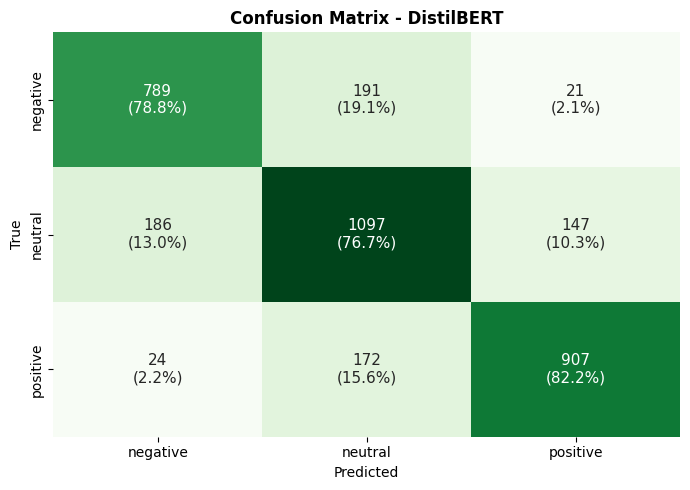

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_confusion_matrix(y_test, y_pred_bert, 'DistilBERT', ax=ax, cmap='Greens')
plt.tight_layout(); plt.show()

In [13]:
show_misclassified(X_test_text, y_test, y_pred_bert, n=5)


 오분류 사례 (5개, 전체 741개 중)
------------------------------------------------------------
[True: negative | Pred: positive]
  → Just read a book called 'Gamer Girl' and it wasn`t too bad.

[True: negative | Pred:  neutral]
  → Waah, asshat at CVS yesterday shortchanged me I paid 10$ for chips.

[True:  neutral | Pred: negative]
  → no cuz i feel the same way..

[True:  neutral | Pred: negative]
  → _a_michael It doesn`t look like you`re tired in the pic. Don`t work too hard.

[True: negative | Pred:  neutral]
  → all alone for the weekend!



### 6. 결과 저장

In [14]:
with open(os.path.join(RESULTS_DIR, 'result_bert.json'), 'w') as f:
    json.dump({k: float(v) if isinstance(v, (int,float,np.floating)) else v
               for k,v in result_bert.items()}, f, indent=2)

np.savez(os.path.join(RESULTS_DIR, 'preds_bert.npz'), y_test=y_test, pred_bert=y_pred_bert)
print('result_bert.json, preds_bert.npz 저장')

result_bert.json, preds_bert.npz 저장
